In [7]:
import pandas as pd


games = pd.read_csv("games.csv")
characters = pd.read_csv("characters.csv")
appearance = pd.read_csv("gameAppearance.csv")
dialogues = pd.read_csv("interactions.csv")
scenes = pd.read_csv("scenes.csv")

In [8]:
games.head()

,id,title,year,type,chronology_order
0,re,Resident Evil,1996,mainline,2
1,re2,Resident Evil 2,1998,mainline,4
2,re3,Resident Evil 3: Nemesis,1999,mainline,3
3,re_ve,Resident Evil: Code – Veronica,2000,mainline,5
4,re0,Resident Evil 0,2002,mainline,1


In [11]:
games.columns
characters.columns
dialogues.columns
scenes.columns

Index(['game_id', 'scene_id', 'title', 'source'], dtype='object')

In [12]:
print("Games:", games.columns)
print("Characters:", characters.columns)
print("Dialogues:", dialogues.columns)
print("Scenes:", scenes.columns)

Games: Index(['id', 'title', 'year', 'type', 'chronology_order'], dtype='object')
Characters: Index(['id', 'name', 'role'], dtype='object')
Dialogues: Index(['game_id', 'scene_id', 'character_id'], dtype='object')
Scenes: Index(['game_id', 'scene_id', 'title', 'source'], dtype='object')


In [14]:
df = dialogues.merge(characters, left_on="character_id", right_on="id")
df = df.merge(games, left_on="game_id", right_on="id")
df = df.merge(scenes, on=["game_id", "scene_id"])
df.head()

,game_id,scene_id,character_id,id_x,name,role,id_y,title_x,year,type,chronology_order,title_y,source
0,re,re_01,16,16,Jill Valentine,hero,re,Resident Evil,1996,mainline,2,Opening FMV,https://gamefaqs.gamespot.com/ps/198462-reside...
1,re,re_01,6,6,Albert Wesker,villain,re,Resident Evil,1996,mainline,2,Opening FMV,https://gamefaqs.gamespot.com/ps/198462-reside...
2,re,re_01,15,15,Chris Redfield,hero,re,Resident Evil,1996,mainline,2,Opening FMV,https://gamefaqs.gamespot.com/ps/198462-reside...
3,re,re_02,16,16,Jill Valentine,hero,re,Resident Evil,1996,mainline,2,Inside The Mansion,https://gamefaqs.gamespot.com/ps/198462-reside...
4,re,re_02,17,17,Barry Burton,hero,re,Resident Evil,1996,mainline,2,Inside The Mansion,https://gamefaqs.gamespot.com/ps/198462-reside...


In [15]:
df = df.rename(columns={
    "title_x": "game_title",
    "title_y": "scene_title"
})

df.head()

,game_id,scene_id,character_id,id_x,name,role,id_y,game_title,year,type,chronology_order,scene_title,source
0,re,re_01,16,16,Jill Valentine,hero,re,Resident Evil,1996,mainline,2,Opening FMV,https://gamefaqs.gamespot.com/ps/198462-reside...
1,re,re_01,6,6,Albert Wesker,villain,re,Resident Evil,1996,mainline,2,Opening FMV,https://gamefaqs.gamespot.com/ps/198462-reside...
2,re,re_01,15,15,Chris Redfield,hero,re,Resident Evil,1996,mainline,2,Opening FMV,https://gamefaqs.gamespot.com/ps/198462-reside...
3,re,re_02,16,16,Jill Valentine,hero,re,Resident Evil,1996,mainline,2,Inside The Mansion,https://gamefaqs.gamespot.com/ps/198462-reside...
4,re,re_02,17,17,Barry Burton,hero,re,Resident Evil,1996,mainline,2,Inside The Mansion,https://gamefaqs.gamespot.com/ps/198462-reside...


In [16]:
##Now Analysis Part:

In [20]:
##1. Top Characters (Who appears most)
df["name"].value_counts().head(10)

name
Grace Ashcroft        267
Leon Scott Kennedy    244
Rosemary Winters      174
Ethan Winters          92
Chris Redfield         78
Claire Redfield        73
Sherry Birkin          70
Jill Valentine         64
Mia Winters            46
Rebecca Chambers       42
Name: count, dtype: int64

In [21]:
##2. Most Active Games
df["game_title"].value_counts()

game_title
Resident Evil Requiem                     548
Resident Evil Village – Shadow of Rose    199
Resident Evil 2                           177
Resident Evil 5                           127
Resident Evil 7: Biohazard                117
Resident Evil: Code – Veronica             70
Resident Evil                              69
Resident Evil 0                            66
Resident Evil 3: Nemesis                   52
Resident Evil 4                            46
Resident Evil 6                            39
Resident Evil Village                      27
Name: count, dtype: int64

In [22]:
##3. Most Active Scenes
df["scene_title"].value_counts().head(10)

scene_title
Chapter 5                     9
Chapter 4                     9
Chapter 2                     8
Radio Transmission #3         8
Slideshow                     8
Chapter 3                     7
Snap out of it.               6
Who the heck are you?         6
I have to find my brother.    6
I have to talk to her.        6
Name: count, dtype: int64

In [25]:
##4. Role Distribution
df["role"].value_counts()

role
hero       1024
support     394
villain     119
Name: count, dtype: int64

In [27]:
##5. Unique Characters per Game
unique_characters = df.groupby("game_title")["name"].nunique()
unique_characters

game_title
Resident Evil                             6
Resident Evil 0                           5
Resident Evil 2                           7
Resident Evil 3: Nemesis                  4
Resident Evil 4                           8
Resident Evil 5                           9
Resident Evil 6                           8
Resident Evil 7: Biohazard                3
Resident Evil Requiem                     6
Resident Evil Village                     8
Resident Evil Village – Shadow of Rose    4
Resident Evil: Code – Veronica            7
Name: name, dtype: int64

In [29]:
##6. Game Timeline Analysis
games_by_year = df.groupby("year")["game_title"].nunique()
games_by_year

year
1996    1
1998    1
1999    1
2000    1
2002    1
2005    1
2009    1
2012    1
2017    1
2021    1
2022    1
2026    1
Name: game_title, dtype: int64

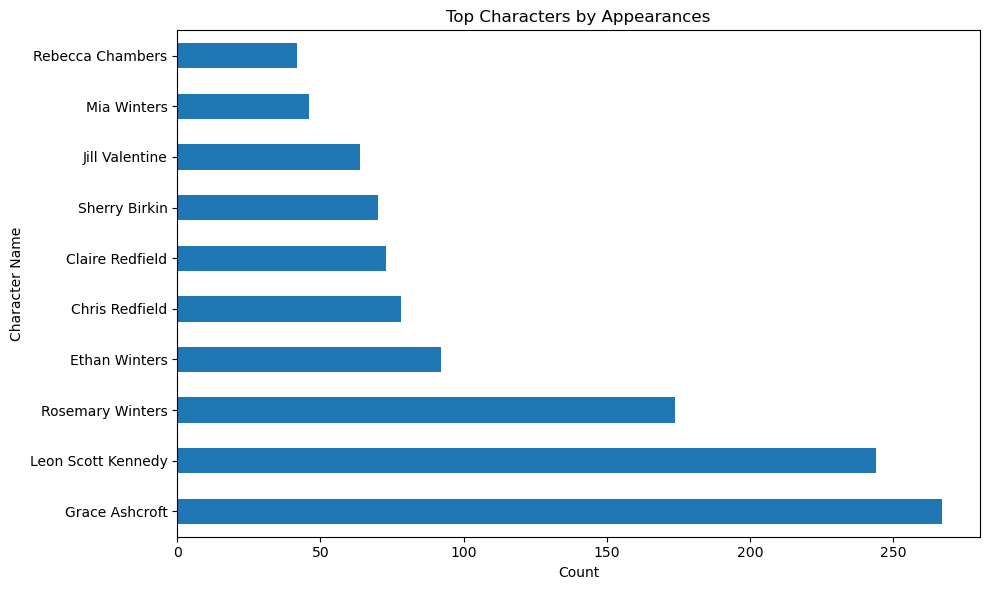

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df["name"].value_counts().head(10).plot(kind='barh')

plt.title("Top Characters by Appearances")
plt.xlabel("Count")
plt.ylabel("Character Name")
plt.tight_layout()
plt.show()

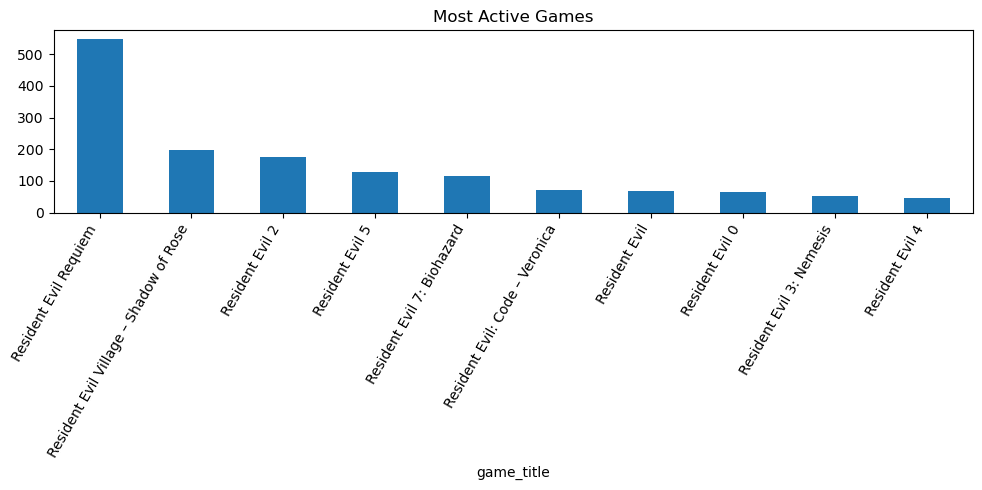

In [31]:
plt.figure(figsize=(10,5))   # increase width

df["game_title"].value_counts().head(10).plot(kind='bar')

plt.title("Most Active Games")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

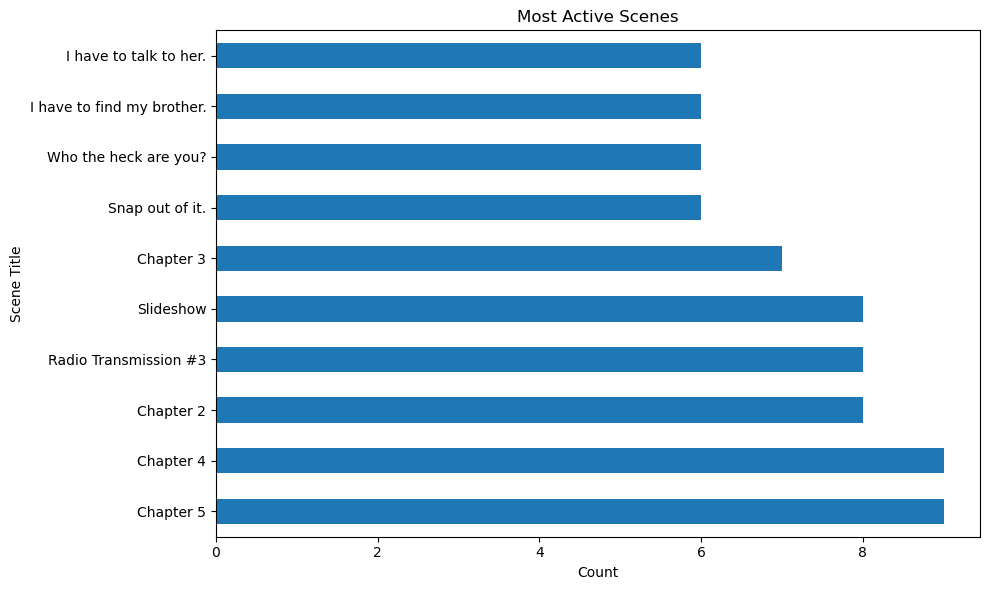

In [33]:
plt.figure(figsize=(10,6))

df["scene_title"].value_counts().head(10).plot(kind='barh')

plt.title("Most Active Scenes")
plt.xlabel("Count")
plt.ylabel("Scene Title")
plt.tight_layout()
plt.show()

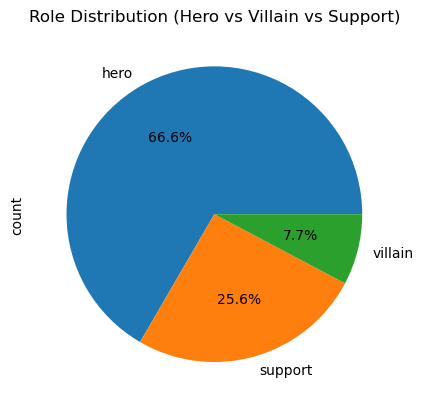

In [35]:
df["role"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Role Distribution (Hero vs Villain vs Support)")
plt.show()

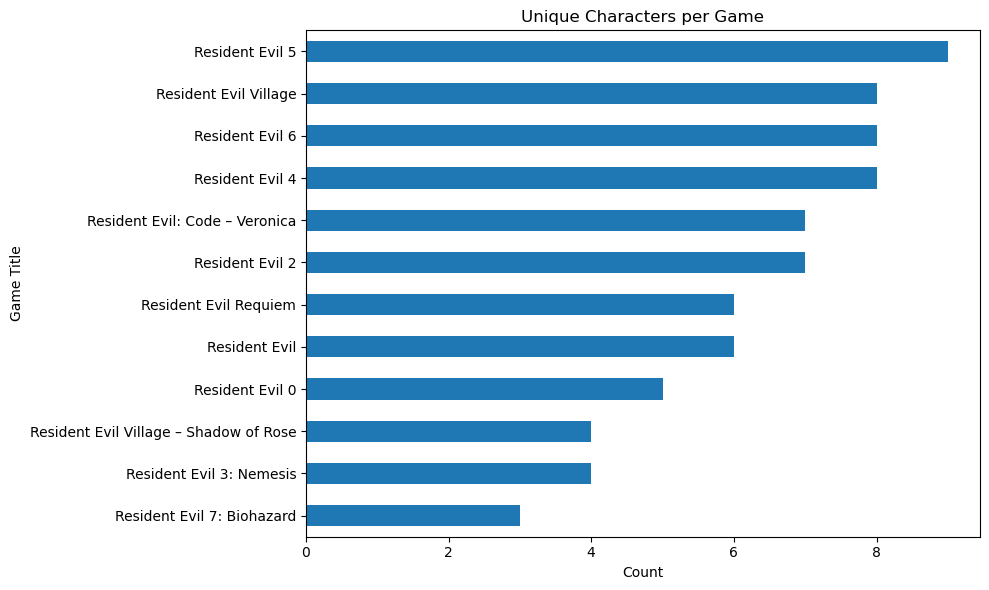

In [36]:
plt.figure(figsize=(10,6))

unique_characters.sort_values().plot(kind='barh')

plt.title("Unique Characters per Game")
plt.xlabel("Count")
plt.ylabel("Game Title")
plt.tight_layout()
plt.show()

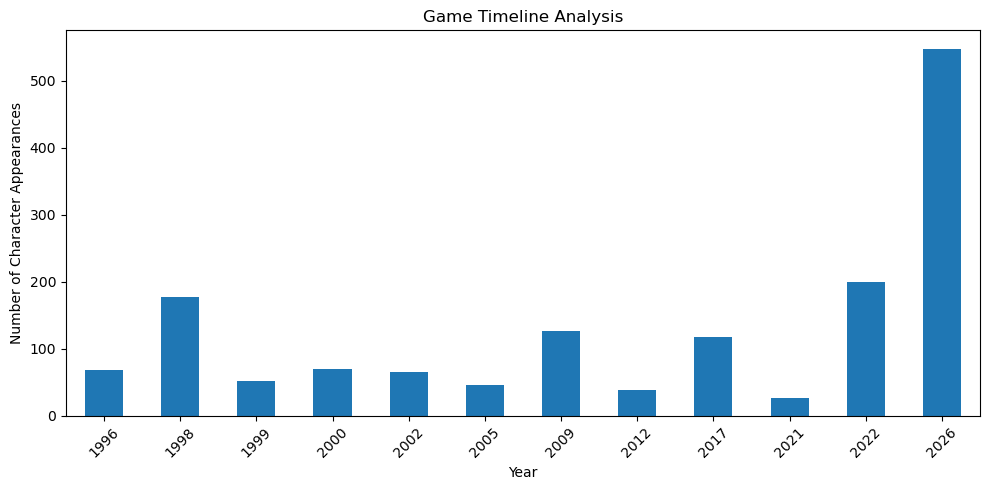

In [39]:
activity_per_year = df.groupby("year").size()

plt.figure(figsize=(10,5))

activity_per_year.plot(kind='bar')

plt.title("Game Timeline Analysis")
plt.xlabel("Year")
plt.ylabel("Number of Character Appearances")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()